# Кластерный анализ механико-гемодинамической адаптации к нагрузке

## Цель этапа

На данном этапе выполняется кластерный анализ внутри группы переменных, описывающих механико-гемодинамическую адаптацию левого желудочка к нагрузке.

В кластеризацию включаются следующие переменные:

- `dsws` — прирост систолического артериального давления на нагрузке;
- `echo_lv_sws_delta_g_cm2` — прирост систолического напряжения стенки ЛЖ;
- `echo_lv_sphericity_index_end_systolic_ratio` — индекс сферичности ЛЖ в конце систолы;
- `echo_lv_sphericity_index_end_diastolic_ratio` — индекс сферичности ЛЖ в конце диастолы.

## Логика этапа

Сначала мы не сравниваем хорды и не строим сложные модели, а пытаемся выделить скрытые фенотипы адаптации ЛЖ к нагрузке на основе трёх физиологических слоёв:

1. гемодинамическая реакция на нагрузку;
2. прирост напряжения стенки ЛЖ;
3. изменение / особенности геометрии ЛЖ.

## Главная идея

`dsws` отражает прирост давления, а `echo_lv_sws_delta_g_cm2` отражает уже расчётную механическую нагрузку на стенку ЛЖ.

Поэтому эти переменные не дублируют друг друга:

```text
dsws = гемодинамическая нагрузка давлением
echo_lv_sws_delta_g_cm2 = механическая нагрузка на стенку ЛЖ

In [1]:
# ============================================================
# 0. Импорты и глобальные настройки
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Настройки pandas
# ------------------------------------------------------------

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

# ------------------------------------------------------------
# Пути
# ------------------------------------------------------------

DATA_PATH = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx")

OUTPUT_DIR = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

# ------------------------------------------------------------
# Академический стиль графиков
# ------------------------------------------------------------

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
plt.rcParams["text.color"] = "black"

plt.rcParams["grid.color"] = "#D9D9D9"
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 0.8

def apply_publication_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.tick_params(axis="both", colors="black", labelsize=10)
    ax.grid(True, axis="y", alpha=0.5)
    return ax

DATA_PATH: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx
OUTPUT_DIR: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load


In [6]:
# ============================================================
# 1. Загрузка данных и выбор переменных кластеризации
# ============================================================

df = pd.read_excel(DATA_PATH)

print(f"Размер исходного датасета: {df.shape[0]} строк × {df.shape[1]} колонок")

cluster_vars = [
    "dsws",
    "echo_lv_sws_delta_g_cm2",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_sphericity_index_end_diastolic_ratio",
]

missing_vars = [col for col in cluster_vars if col not in df.columns]
existing_vars = [col for col in cluster_vars if col in df.columns]

print("\nНайдены переменные:")
for col in existing_vars:
    print("  -", col)

if missing_vars:
    print("\nНЕ найдены переменные:")
    for col in missing_vars:
        print("  -", col)
else:
    print("\nВсе переменные для текущего этапа найдены.")

cluster_df = df[existing_vars].copy()

cluster_df.head()

Размер исходного датасета: 153 строк × 222 колонок

Найдены переменные:
  - dsws
  - echo_lv_sws_delta_g_cm2
  - echo_lv_sphericity_index_end_systolic_ratio
  - echo_lv_sphericity_index_end_diastolic_ratio

Все переменные для текущего этапа найдены.


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
0,37.0,35.371669,0.463,0.343
1,NaN,NaN,NaN,NaN
2,42.0,38.579679,0.505,0.602
3,46.0,40.536860,0.514,0.400
4,21.0,26.281070,0.576,0.530


In [3]:
# ============================================================
# 2. Первичный аудит: типы, пропуски, размер рабочей выборки
# ============================================================

audit_table = pd.DataFrame({
    "variable": cluster_df.columns,
    "dtype": cluster_df.dtypes.astype(str).values,
    "n_missing": cluster_df.isna().sum().values,
    "pct_missing": (cluster_df.isna().mean() * 100).round(2).values,
    "n_unique": cluster_df.nunique(dropna=True).values,
})

display(audit_table)

complete_cases_mask = cluster_df.notna().all(axis=1)
cluster_df_complete = cluster_df.loc[complete_cases_mask].copy()

print(f"\nПолная выборка: {cluster_df.shape[0]} наблюдений")
print(f"Полные случаи для кластеризации: {cluster_df_complete.shape[0]} наблюдений")
print(f"Исключено из-за пропусков: {cluster_df.shape[0] - cluster_df_complete.shape[0]}")

,variable,dtype,n_missing,pct_missing,n_unique
0,dsws,float64,87,56.86,30
1,vo2_max_absolute_ml_min,float64,94,61.44,5
2,echo_lv_sphericity_index_end_systolic_ratio,float64,53,34.64,74
3,echo_lv_sphericity_index_end_diastolic_ratio,float64,53,34.64,72



Полная выборка: 153 наблюдений
Полные случаи для кластеризации: 59 наблюдений
Исключено из-за пропусков: 94


In [4]:
# ============================================================
# 3. Описательная статистика по переменным кластеризации
# ============================================================

desc = cluster_df_complete.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc["missing_in_original_n"] = cluster_df.isna().sum()
desc["missing_in_original_pct"] = (cluster_df.isna().mean() * 100).round(2)

display(desc)

desc.to_excel(TABLES_DIR / "descriptive_statistics_cluster_variables.xlsx")
print("Таблица сохранена:", TABLES_DIR / "descriptive_statistics_cluster_variables.xlsx")

,count,mean,std,min,5%,25%,50%,75%,95%,max,missing_in_original_n,missing_in_original_pct
dsws,59.0,23.050847,10.841211,-3.000,5.9000,16.500,24.000,29.000,40.2000,47.000,87,56.86
vo2_max_absolute_ml_min,59.0,48.988136,10.605469,30.800,30.8000,38.500,46.550,54.600,63.0000,63.000,94,61.44
echo_lv_sphericity_index_end_systolic_ratio,59.0,0.429525,0.063339,0.328,0.3477,0.378,0.414,0.478,0.5467,0.576,53,34.64
echo_lv_sphericity_index_end_diastolic_ratio,59.0,0.508085,0.066757,0.343,0.4333,0.465,0.494,0.558,0.6060,0.689,53,34.64


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\tables\descriptive_statistics_cluster_variables.xlsx


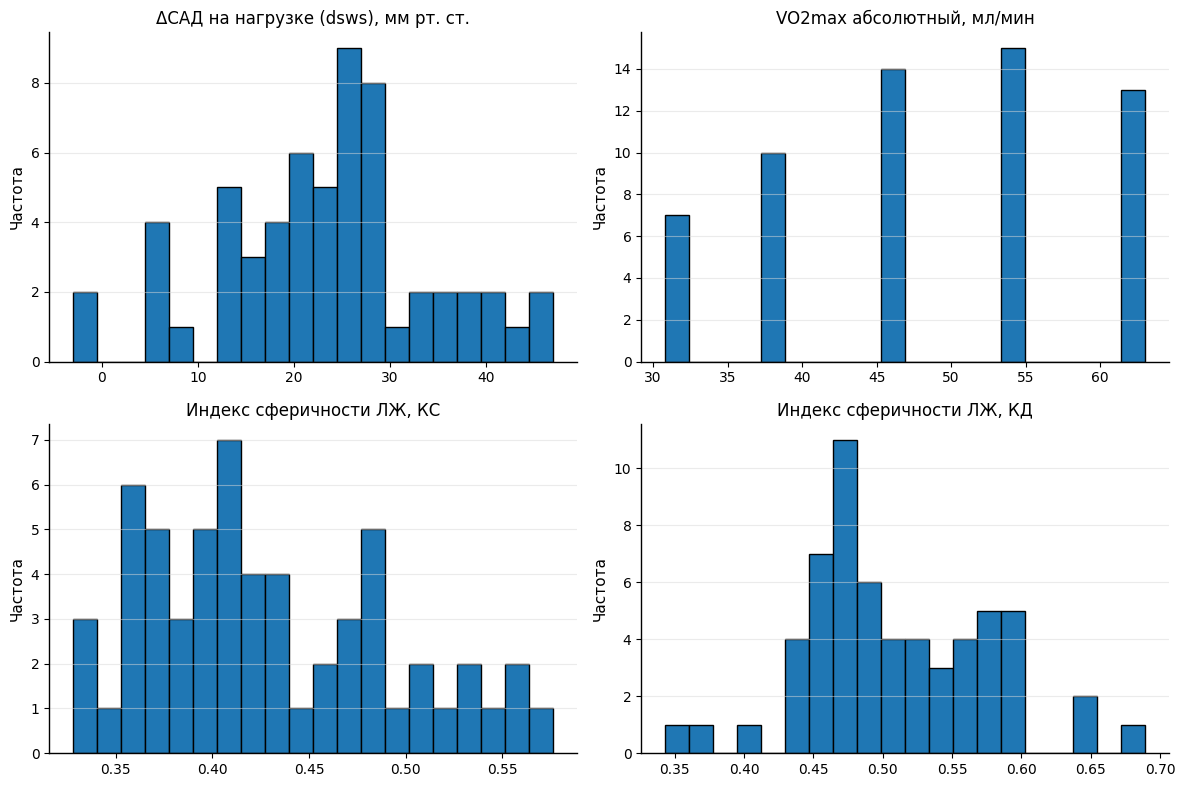

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\01_distributions_cluster_variables.png


In [ ]:
# ============================================================
# 4. Распределения переменных
# ============================================================

pretty_names = {
    "dsws": "ΔСАД на нагрузке, мм рт. ст.",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, cluster_df_complete.columns):
    values = cluster_df_complete[col].dropna()

    ax.hist(values, bins=20, edgecolor="black", linewidth=1.0)
    ax.set_title(pretty_names.get(col, col))
    ax.set_xlabel("")
    ax.set_ylabel("Частота")
    apply_publication_style(ax)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_distributions_cluster_variables.png", dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", FIGURES_DIR / "01_distributions_cluster_variables.png")